In [3]:
# Imports
import os
import cv2
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = "2" 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from collections import Counter

In [4]:
# Parameters
IMG_SIZE = 128
DATA_PATH = "../Data/Scores"
BATCH_SIZE = 16
EPOCHS = 30

In [5]:
# Data Loading
print("[INFO] Loading dataset...")
X, y, class_names = [], [], []
class_map = {}

for shape_name in os.listdir(DATA_PATH): 
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue
    
    for score in os.listdir(shape_path): 
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue
        
        label = f"{shape_name}_{score}"
        if label not in class_map:
            class_map[label] = len(class_map)
            class_names.append(label)
        
        for file in os.listdir(score_path):
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                path = os.path.join(score_path, file)
                img = cv2.imread(path)
                if img is None:
                    continue
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(class_map[label])

X = np.array(X, dtype="float32")
y = np.array(y)

print(f"[INFO] Dataset loaded: {X.shape[0]} samples, {len(class_map)} classes")

[INFO] Loading dataset...
[INFO] Dataset loaded: 4298 samples, 34 classes


In [6]:
# Filter out classes with only 1 sample - currently not use
counts = Counter(y)
valid_classes = [cls for cls, c in counts.items() if c > 1]

X_filtered = []
y_filtered = []
for xi, yi in zip(X, y):
    if yi in valid_classes:
        X_filtered.append(xi)
        y_filtered.append(yi)

X = np.array(X_filtered)
y = np.array(y_filtered)

In [7]:
# Remap labels
unique_classes = sorted(set(y))
class_mapping = {cls: idx for idx, cls in enumerate(unique_classes)}
y_mapped = np.array([class_mapping[yi] for yi in y])
num_classes = len(unique_classes)

print(f"[INFO] After filtering: {len(X)} samples, {num_classes} classes")

[INFO] After filtering: 4295 samples, 31 classes


In [8]:
# One-hot encode
y_cat = to_categorical(y_mapped, num_classes=num_classes)

In [9]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_mapped
)
print(f"[INFO] Train: {X_train.shape}, Test: {X_test.shape}")

[INFO] Train: (3436, 128, 128, 3), Test: (859, 128, 128, 3)


In [10]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.15,
    fill_mode='nearest',
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

In [11]:
# For test/validation 
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

In [13]:
# Model Bulid
base_model = ResNet50(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet' 
)

In [14]:
# Freeze base model initially
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

In [15]:
# Complation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │        15,903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,662,943 (94.08 MB)

 Trainable params: 1,070,111 (4.08 MB)

 Non-trainable params: 23,592,832 (90.00 MB)

In [16]:
# Callback
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        './best_resnet_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [17]:
# Training Phase-1
print("\n[INFO] Phase 1: Training with frozen base model...")
history1 = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=test_datagen.flow(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False),
    epochs=20,
    callbacks=callbacks,
    verbose=1
)


[INFO] Phase 1: Training with frozen base model...


/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.5057 - loss: 2.0327 
Epoch 1: val_accuracy improved from -inf to 0.66938, saving model to ./best_resnet_model.h5


215/215 ━━━━━━━━━━━━━━━━━━━━ 52s 218ms/step - accuracy: 0.5060 - loss: 2.0308 - val_accuracy: 0.6694 - val_loss: 1.0611 - learning_rate: 0.0010
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.6218 - loss: 1.2817 
Epoch 2: val_accuracy improved from 0.66938 to 0.71362, saving model to ./best_resnet_model.h5


215/215 ━━━━━━━━━━━━━━━━━━━━ 46s 212ms/step - accuracy: 0.6219 - loss: 1.2813 - val_accuracy: 0.7136 - val_loss: 0.9781 - learning_rate: 0.0010
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.6814 - loss: 1.0511 
Epoch 3: val_accuracy improved from 0.71362 to 0.74971, saving model to ./best_resnet_model.h5


215/215 ━━━━━━━━━━━━━━━━━━━━ 45s 208ms/step - accuracy: 0.6814 - loss: 1.0511 - val_accuracy: 0.7497 - val_loss: 0.8723 - learning_rate: 0.0010
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.6700 - loss: 0.9864 
Epoch 4: val_accuracy improved from 0.74971 to 0.75902, saving model to ./best_resnet_model.h5


215/215 ━━━━━━━━━━━━━━━━━━━━ 46s 212ms/step - accuracy: 0.6701 - loss: 0.9864 - val_accuracy: 0.7590 - val_loss: 0.8085 - learning_rate: 0.0010
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.6985 - loss: 0.9463 
Epoch 5: val_accuracy did not improve from 0.75902
215/215 ━━━━━━━━━━━━━━━━━━━━ 45s 209ms/step - accuracy: 0.6985 - loss: 0.9463 - val_accuracy: 0.7474 - val_loss: 0.7906 - learning_rate: 0.0010
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6913 - loss: 0.9168 
Epoch 6: val_accuracy did not improve from 0.75902
215/215 ━━━━━━━━━━━━━━━━━━━━ 45s 208ms/step - accuracy: 0.6914 - loss: 0.9168 - val_accuracy: 0.7241 - val_loss: 0.8316 - learning_rate: 0.0010
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.7144 - loss: 0.8397 
Epoch 7: val_accuracy did not improve from 0.75902
215/215 ━━━━━━━━━━━━━━━━━━━━ 45s 210ms/step - accuracy: 0.7144 - loss: 0.8397 - val_accuracy: 0.7113 - val_loss: 0.8145 - learning_rate: 0.0010
Epoc

In [18]:
# Training Phase-2
print("\n[INFO] Phase 2: Fine-tuning - unfreezing base model...")
base_model.trainable = True

# Freeze early layers, fine-tune later layers
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=test_datagen.flow(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False),
    epochs=30,
    callbacks=callbacks,
    initial_epoch=len(history1.history['loss']),
    verbose=1
)


[INFO] Phase 2: Fine-tuning - unfreezing base model...
Epoch 21/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.6764 - loss: 0.9339  
Epoch 21: val_accuracy did not improve from 0.75902
215/215 ━━━━━━━━━━━━━━━━━━━━ 151s 645ms/step - accuracy: 0.6765 - loss: 0.9335 - val_accuracy: 0.7276 - val_loss: 0.8391 - learning_rate: 1.0000e-04
Epoch 22/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.7365 - loss: 0.7803  
Epoch 22: val_accuracy did not improve from 0.75902
215/215 ━━━━━━━━━━━━━━━━━━━━ 138s 640ms/step - accuracy: 0.7365 - loss: 0.7803 - val_accuracy: 0.7532 - val_loss: 0.7389 - learning_rate: 1.0000e-04
Epoch 23/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.7514 - loss: 0.7268  
Epoch 23: val_accuracy did not improve from 0.75902
215/215 ━━━━━━━━━━━━━━━━━━━━ 138s 640ms/step - accuracy: 0.7514 - loss: 0.7268 - val_accuracy: 0.7474 - val_loss: 0.7747 - learning_rate: 1.0000e-04
Epoch 24/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0

215/215 ━━━━━━━━━━━━━━━━━━━━ 139s 644ms/step - accuracy: 0.7570 - loss: 0.7102 - val_accuracy: 0.7602 - val_loss: 0.7654 - learning_rate: 1.0000e-04
Epoch 25/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.7683 - loss: 0.6513  
Epoch 25: val_accuracy did not improve from 0.76019
215/215 ━━━━━━━━━━━━━━━━━━━━ 137s 638ms/step - accuracy: 0.7682 - loss: 0.6514 - val_accuracy: 0.7241 - val_loss: 0.7940 - learning_rate: 1.0000e-04
Epoch 26/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.7524 - loss: 0.6486  
Epoch 26: val_accuracy did not improve from 0.76019
215/215 ━━━━━━━━━━━━━━━━━━━━ 138s 640ms/step - accuracy: 0.7524 - loss: 0.6487 - val_accuracy: 0.7520 - val_loss: 0.7540 - learning_rate: 1.0000e-04
Epoch 27/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.7881 - loss: 0.6149  
Epoch 27: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 27: val_accuracy did not improve from 0.76019
215/215 ━━━━━━━━━━━━━━━━━━━━ 137s 638ms/step -

215/215 ━━━━━━━━━━━━━━━━━━━━ 140s 651ms/step - accuracy: 0.7727 - loss: 0.6166 - val_accuracy: 0.7660 - val_loss: 0.7646 - learning_rate: 5.0000e-05
Epoch 29/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.7902 - loss: 0.5874  
Epoch 29: val_accuracy improved from 0.76601 to 0.77532, saving model to ./best_resnet_model.h5


215/215 ━━━━━━━━━━━━━━━━━━━━ 138s 643ms/step - accuracy: 0.7902 - loss: 0.5874 - val_accuracy: 0.7753 - val_loss: 0.7441 - learning_rate: 5.0000e-05
Epoch 30/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.7861 - loss: 0.5941  
Epoch 30: val_accuracy improved from 0.77532 to 0.77648, saving model to ./best_resnet_model.h5


215/215 ━━━━━━━━━━━━━━━━━━━━ 139s 644ms/step - accuracy: 0.7861 - loss: 0.5940 - val_accuracy: 0.7765 - val_loss: 0.7750 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 22.


In [19]:
# Combine histories
history_combined = {
    'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
    'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'],
    'loss': history1.history['loss'] + history2.history['loss'],
    'val_loss': history1.history['val_loss'] + history2.history['val_loss']
}

In [20]:
# Evaluation
print("\n[INFO] Evaluating model...")
test_loss, test_acc = model.evaluate(
    test_datagen.flow(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False),
    verbose=0
)
print(f"[RESULT] Test Accuracy: {test_acc:.4f}")
print(f"[RESULT] Test Loss: {test_loss:.4f}")


[INFO] Evaluating model...
[RESULT] Test Accuracy: 0.7532
[RESULT] Test Loss: 0.7389


In [21]:
# Predictions
y_pred = model.predict(test_datagen.flow(X_test, batch_size=BATCH_SIZE, shuffle=False))
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Cohen's Kappa
kappa = cohen_kappa_score(y_true, y_pred_classes)
print(f"[RESULT] Cohen's Kappa: {kappa:.4f}")

54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step
[RESULT] Cohen's Kappa: 0.7272


In [26]:
# Classification Report
#print("\n[INFO] Classification Report:")
# print(classification_report(
#     y_true,
#     y_pred_classes,
#     target_names=[class_names[i] for i in unique_classes],
#     zero_division=0
# ))

# unique_classes = np.unique(y_true)

# print("\n[INFO] Classification Report:")
# print(classification_report(
#     y_true,
#     y_pred_classes,
#     labels=unique_classes,
#     target_names=[class_names[i] for i in unique_classes],
#     zero_division=0
# ))

In [25]:
print("\n[INFO] Classification Report:")
print(classification_report(
    y_true,
    y_pred_classes,
    labels=range(len(class_names)),   # 0 to 30
    target_names=class_names,
    zero_division=0
))



[INFO] Classification Report:
                      precision    recall  f1-score   support

          Triangle_0       0.00      0.00      0.00         1
          Triangle_4       0.00      0.00      0.00         8
          Triangle_5       0.93      0.96      0.95       108
              Star_3       0.33      0.30      0.32        20
              Star_2       0.00      0.00      0.00         2
              Star_0       0.00      0.00      0.00         3
              Star_4       0.51      0.82      0.63        50
              Star_5       0.00      0.00      0.00        20
              Wave_3       0.40      0.18      0.25        22
              Wave_2       0.00      0.00      0.00         1
              Wave_0       0.00      0.00      0.00         0
              Wave_4       0.81      0.91      0.86        87
            Circle_3       1.00      0.05      0.09        22
            Circle_2       0.00      0.00      0.00         1
            Circle_0       0.81      1

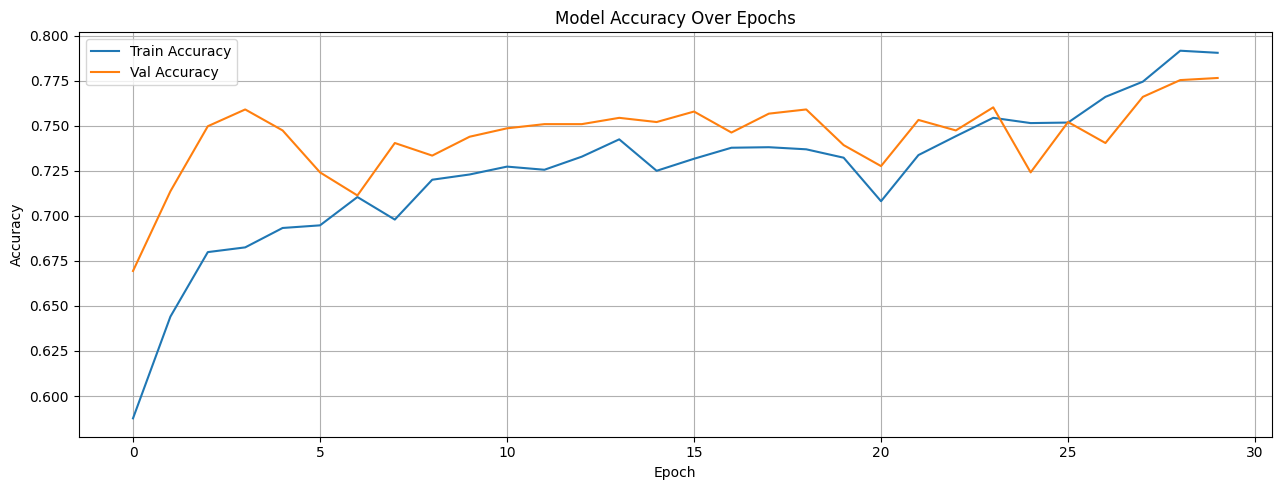

In [28]:
# Plot accuracy
plt.figure(figsize=(25, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_combined['accuracy'], label='Train Accuracy')
plt.plot(history_combined['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

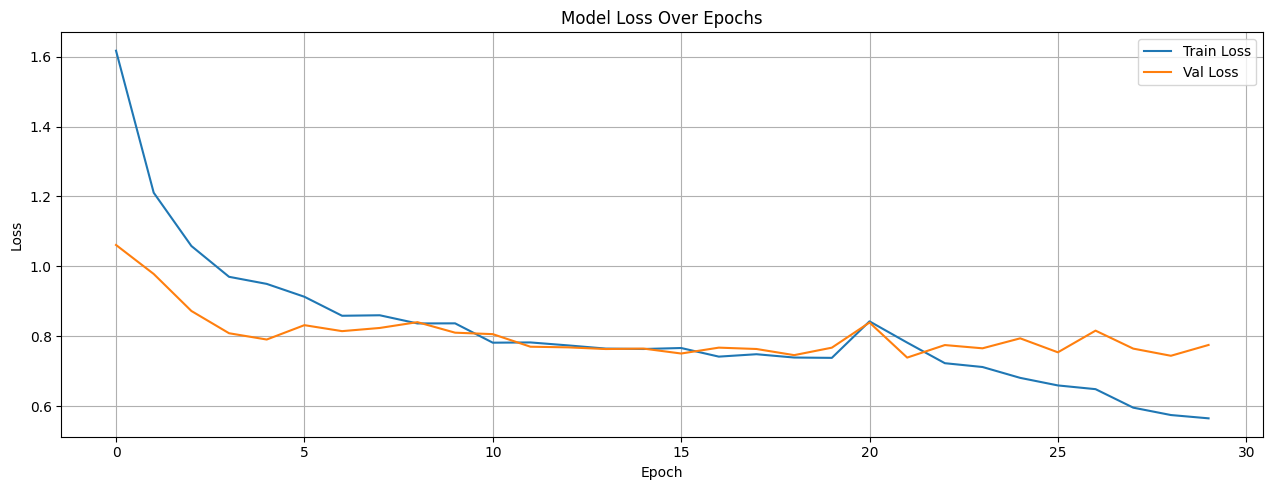

In [30]:
# plot Loss
plt.figure(figsize=(25, 5))

plt.subplot(1, 2, 2)
plt.plot(history_combined['loss'], label='Train Loss')
plt.plot(history_combined['val_loss'], label='Val Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step


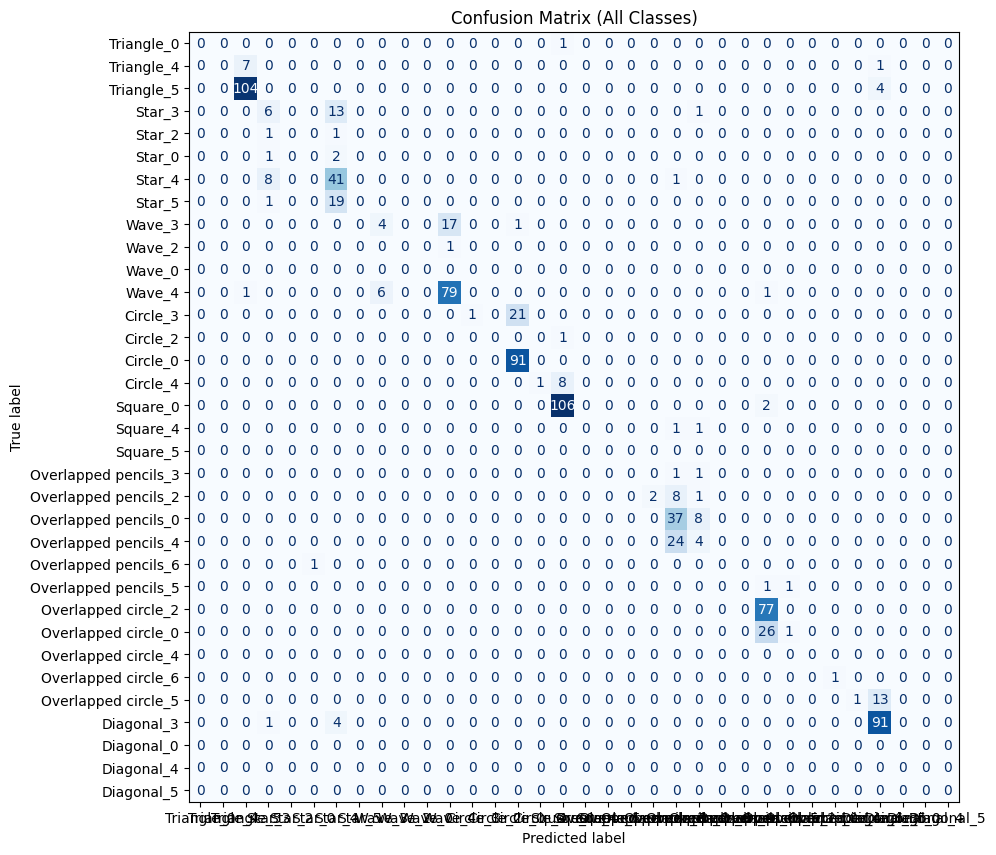

In [35]:
# Predict
y_pred_probs = model.predict(test_datagen.flow(X_test, batch_size=BATCH_SIZE, shuffle=False))
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Get only the unique classes present
unique_classes = np.unique(y_true)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes, labels=unique_classes)

# Display only those class names
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[class_names[i] for i in unique_classes])

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")
plt.show()

/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 204ms/step


<Figure size 2400x600 with 0 Axes>

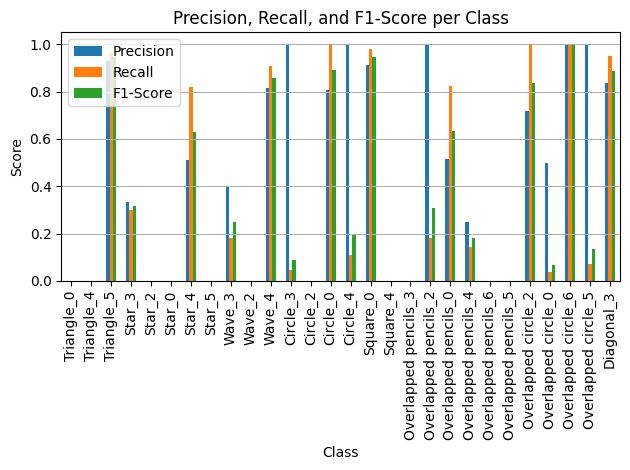

In [47]:
# Predict again if not already done
y_pred_probs = model.predict(test_datagen.flow(X_test, batch_size=BATCH_SIZE, shuffle=False))
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Get metrics for only the classes that appear in y_true
unique_classes = np.unique(y_true)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred_classes, labels=unique_classes, zero_division=0)

# Create a DataFrame (matching lengths)
metrics_df = pd.DataFrame({
    'Class': [class_names[i] for i in unique_classes],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
})

# Plot
plt.figure(figsize=(24, 6))
metrics_df.set_index('Class')[['Precision', 'Recall', 'F1-Score']].plot(kind='bar')
plt.title('Precision, Recall, and F1-Score per Class')
plt.xlabel('Class')
plt.ylabel('Score')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [37]:
# Save Model
SAVE_DIR = "./model_outputs/resNet"
os.makedirs(SAVE_DIR, exist_ok=True)

In [38]:
# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history_combined['accuracy'], label='Train Accuracy')
plt.plot(history_combined['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "accuracy_plot.png"))
plt.close()

In [39]:
# Save Loss Plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 2)
plt.plot(history_combined['loss'], label='Train Loss')
plt.plot(history_combined['val_loss'], label='Val Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "loss_plot.png"))
plt.close()

In [40]:
# Save trained model
model.save(os.path.join(SAVE_DIR, "resNet_model.h5"))
print("[INFO] Model saved successfully")

[INFO] Model saved successfully


In [43]:
# Save training history as JSON
with open(os.path.join(SAVE_DIR, "training_history_resNet.json"), "w") as f:
    json.dump(history_combined, f)

print("[INFO] Combined training history saved as JSON")

[INFO] Combined training history saved as JSON


In [45]:
# Save training history
pd.DataFrame(history_combined).to_csv(
    os.path.join(SAVE_DIR, "resNet_training_history.csv"),
    index=False
)
print("[INFO] Combined training history saved as CSV")

[INFO] Combined training history saved as CSV


In [46]:
# Convert to DataFrame
report_dict = classification_report(
    y_true, 
    y_pred_classes,
    labels=np.arange(len(class_map)),
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

# Save Classification report
report_path = os.path.join(SAVE_DIR, "resNet_classification_report.csv")
report_df.to_csv(report_path, index=True)

print("[INFO] Save Classification report as CSV")

[INFO] Save Classification report as CSV


In [49]:
# Predict
y_pred_probs = model.predict(test_datagen.flow(X_test, batch_size=BATCH_SIZE, shuffle=False))
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Match class names and labels
unique_classes = np.unique(y_true)
cm = confusion_matrix(y_true, y_pred_classes, labels=unique_classes)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[class_names[i] for i in unique_classes])
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")

# Save
save_path = os.path.join(SAVE_DIR, "confusion_matrix_resNet.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"[INFO] Confusion matrix image saved → {save_path}")

/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step
[INFO] Confusion matrix image saved → ./model_outputs/resNet/confusion_matrix_resNet.png


In [50]:
# Plot Precision, Recall, and F1-Score per Class
plt.figure(figsize=(14, 6))
metrics_df.set_index('Class')[['Precision', 'Recall', 'F1-Score']].plot(kind='bar')

plt.title('Precision, Recall, and F1-Score per Class')
plt.xlabel('Class')
plt.ylabel('Score')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()

# Save 
save_path = os.path.join(SAVE_DIR, "precision_recall_f1_resNet.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.close() 

print(f"[INFO] Precision–Recall–F1 chart saved → {save_path}")

[INFO] Precision–Recall–F1 chart saved → ./model_outputs/resNet/precision_recall_f1_resNet.png


<Figure size 1400x600 with 0 Axes>